In [10]:
import pandas as pd

df = pd.read_csv('output_ecoli.tsv', sep='\t')

In [11]:
df.head()

,key,consensus_value,homopolymer_length,consensus_count,neighbor_count,total_count,SUBSTITUTION(AC),SUBSTITUTION(AG),SUBSTITUTION(AT),SUBSTITUTION(GA),...,SUBSTITUTION(TG),INSERTION(A),INSERTION(C),INSERTION(G),INSERTION(T),DELETION(A),DELETION(C),DELETION(G),DELETION(T),AMBIGUOUS
0,CTGAAACTGACTGAACTAATT,GAGTCA,2,11,0,11,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CGGCCTGCTGGATGGGTATTT,CCACCA,3,13,1,14,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,CGTTTATGTCCCTGGTGGTGT,CGTTGT,2,6,0,6,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CCAGCAATGCACGGGTTAACC,GCTTGC,2,10,0,10,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,GCAAAAATCGGCAACATCAAA,TACAAC,3,6,0,7,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
df['SUBSTITUTION'] = df[[col for col in df.columns if col.startswith('SUBSTITUTION')]].sum(axis=1)
df['INSERTION'] = df[[col for col in df.columns if col.startswith('INSERTION')]].sum(axis=1)
df['DELETION'] = df[[col for col in df.columns if col.startswith('DELETION')]].sum(axis=1)

In [18]:
df['non_substitution_neighbors'] = df['neighbor_count'] + df['consensus_count'] - df['SUBSTITUTION']

In [59]:
df[df["ratio"] > 1]

,Key,Consensus_Value,Consensus_Count,Error_Count,Total_Count,Homopolymer_Length,ratio
9,TTTTGTTACGACCAAAGCCAT,ATCCCG,4,10,21,3,2.500000
11,CTGTTCCTGCCATTATGCCAA,ACCCGA,17,22,50,3,1.294118
14,GCTTGAAAATCATTTTCTTCC,CCCGTG,26,34,81,5,1.307692
15,CATACTATTTTTTGGTGAAAA,ATGTTC,9,11,25,5,1.222222
16,CGGAGCAGCTGCAAGCTTTAT,ACGACA,25,28,60,1,1.120000
...,...,...,...,...,...,...,...
3959,AAAACAAAGGTCAGCAAAACG,AAAGAT,48,53,110,3,1.104167
3961,TCCCATGAAACATAAACAACT,GCGGCA,30,31,71,2,1.033333
3966,CCTCAAAAACCGACAAACGCA,GCGGCG,8,11,21,2,1.375000
3969,ATAAATATACTAATCATGTAA,GCCATC,19,22,51,2,1.157895


<Axes: xlabel='SUBSTITUTION', ylabel='non_substitution_neighbors'>

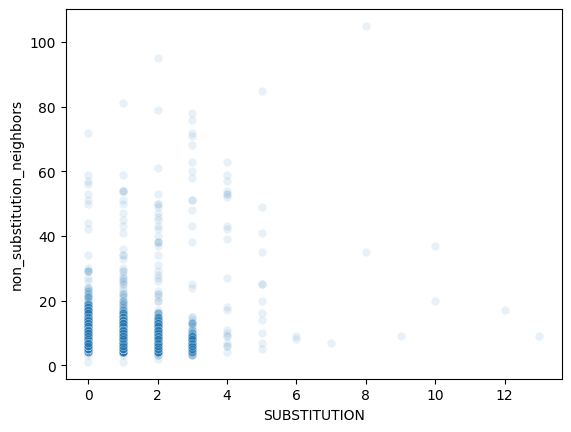

In [19]:
import seaborn as sns
import numpy as np

temp_df = df#[df["Consensus_Count"] > 10]
sns.scatterplot(data=temp_df, x="SUBSTITUTION", y="non_substitution_neighbors", alpha=0.1)

<Axes: xlabel='homopolymer_length', ylabel='ratio'>

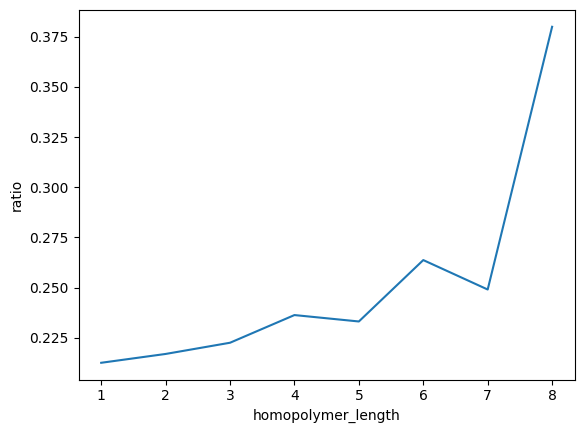

In [9]:
# Plot average ratio w.r.t. homopolymer length
avg_ratio = df.groupby("homopolymer_length")["ratio"].mean().reset_index()
sns.lineplot(data=avg_ratio, x="homopolymer_length", y="ratio")

In [29]:
df[df["Homopolymer_Length"] == 12]

,Key,Consensus_Value,Consensus_Count,Error_Count,Total_Count,Homopolymer_Length,ratio,pred
19072,AAATCAAATGTTTTTTTTTTT,TGCTGA,4,3,21,12,0.75,0.837364


In [54]:
df[df["Total_Count"] > 50]["ratio"].median() / 6

0.03021175611537057

In [55]:
len(df[df["Total_Count"] > 50])

96

/tmp/ipykernel_2131/1553159645.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df["pred"] = model.predict(temp_df[["consensus_count"]])


<Axes: xlabel='consensus_count', ylabel='neighbor_count'>

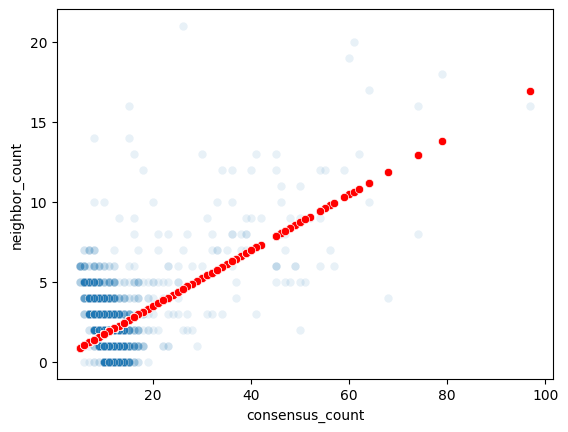

In [30]:
# Linear regression of Error_Count ~ Consensus_Count

from sklearn.linear_model import LinearRegression, QuantileRegressor
import matplotlib.pyplot as plt
temp_df = df[df["total_count"] > 10]
y = temp_df["neighbor_count"]

model = LinearRegression(fit_intercept=False)
model.fit(temp_df[["consensus_count"]], y)
temp_df["pred"] = model.predict(temp_df[["consensus_count"]])
sns.scatterplot(data=temp_df, x="consensus_count", y=y, alpha=0.1)
sns.scatterplot(data=temp_df, x="consensus_count", y="pred", color='red')


/home/zhenhao/miniconda3/lib/python3.8/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- non_substitution_neighbors
Feature names seen at fit time, yet now missing:
- consensus_count

  warnings.warn(message, FutureWarning)
/tmp/ipykernel_2131/604094364.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df["pred"] = model.predict(temp_df[["non_substitution_neighbors"]])


<Axes: xlabel='non_substitution_neighbors', ylabel='None'>

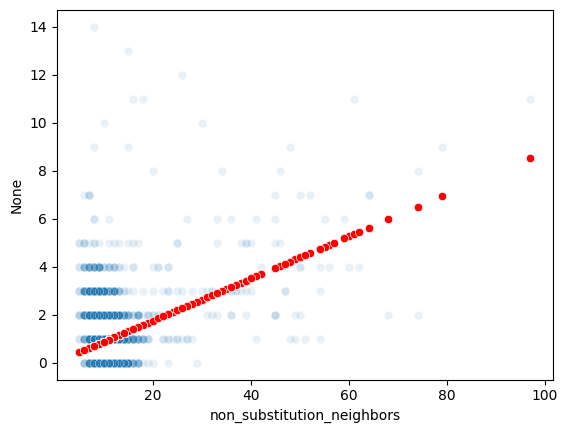

In [33]:
from sklearn.linear_model import LinearRegression, QuantileRegressor
import matplotlib.pyplot as plt
temp_df = df[df["total_count"] > 10]
y = temp_df["SUBSTITUTION"] + temp_df["AMBIGUOUS"]
df['non_substitution_neighbors'] = df['consensus_count']
model = LinearRegression(fit_intercept=False)
model.fit(temp_df[["consensus_count"]], y)
temp_df["pred"] = model.predict(temp_df[["non_substitution_neighbors"]])
sns.scatterplot(data=temp_df, x="non_substitution_neighbors", y=y, alpha=0.1)
sns.scatterplot(data=temp_df, x="non_substitution_neighbors", y="pred", color='red')

In [34]:
model.coef_, model.intercept_

(array([0.08786134]), 0.0)

In [45]:
1 - (1 / 0.16243141) ** (1/6)

-0.35380152078573235

In [32]:
0.17460683 / 6

0.029101138333333332

In [35]:
0.08786134 / 6

0.014643556666666667

/tmp/ipykernel_4965/3106696079.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df["pred"] = model.predict(temp_df[["Consensus_Count"]])


<Axes: xlabel='Consensus_Count', ylabel='Error_Count'>

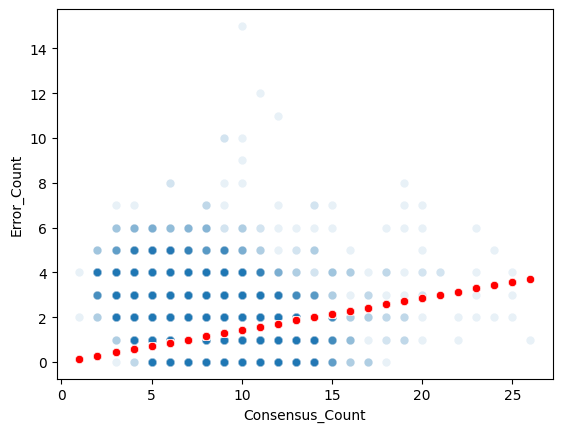

In [260]:
from sklearn.linear_model import LinearRegression, QuantileRegressor

y = temp_df["Error_Count"]

model = QuantileRegressor(quantile=0.5, alpha=1e-6, fit_intercept=False, solver="highs-ds")
model.fit(temp_df[["Consensus_Count"]], y)
temp_df["pred"] = model.predict(temp_df[["Consensus_Count"]])
sns.scatterplot(data=temp_df, x="Consensus_Count", y=y, alpha=0.1)
sns.scatterplot(data=temp_df, x="Consensus_Count", y="pred", color='red')

In [261]:
model.coef_, model.intercept_

(array([0.14285714]), 0.0)

In [215]:
0.15384615 / 6

0.025641024999999998

In [176]:
import torch

def lad_pseudo_huber(X, y, delta=0.01, lr=0.1, steps=2000, l2=0.0, use_lbfgs=False, seed=0, standardize=True):
    torch.manual_seed(seed)
    X = torch.as_tensor(X, dtype=torch.float32)
    y = torch.as_tensor(y, dtype=torch.float32).view(-1)

    # Standardize
    if standardize:
        mu = X.mean(0, keepdim=True)
        sigma = X.std(0, keepdim=True) + 1e-12
        Xs = (X - mu) / sigma
    else:
        mu = torch.zeros(1, X.shape[1]); sigma = torch.ones(1, X.shape[1]); Xs = X

    d = X.shape[1]
    b = torch.zeros(d, requires_grad=True)

    def loss_fn():
        r = y - (Xs @ b)
        # pseudo-Huber
        ph = delta**2 * (torch.sqrt(1.0 + (r/delta)**2) - 1.0)
        reg = 0.5 * l2 * (b @ b)
        return ph.mean() + reg

    if use_lbfgs:
        opt = torch.optim.LBFGS([b], max_iter=200, line_search_fn="strong_wolfe")
        def closure():
            opt.zero_grad()
            L = loss_fn()
            L.backward()
            return L
        for _ in range(20):
            opt.step(closure)
    else:
        opt = torch.optim.Adam([b], lr=lr)
        for _ in range(steps):
            opt.zero_grad()
            L = loss_fn()
            L.backward()
            opt.step()

    # De-standardize
    b_unscaled = (b / sigma.squeeze()).detach().numpy()
    return b_unscaled
    return b0_unscaled, b_unscaled

In [177]:
lad_pseudo_huber(temp_df[["Consensus_Count"]].values, temp_df["Error_Count"].values, delta=1.0, lr=0.1, steps=2000, l2=0.0, use_lbfgs=False, seed=0, standardize=True)

array([0.05126309], dtype=float32)

In [114]:
0.125 / 6

0.020833333333333332